# Laboratorio 1 - Cartografía de Aptitud Solar (Regiones II y III)

**Grupo:** 4 - Plantas solares

---

## Introducción y Pregunta

El propósito de este laboratorio es la construcción de un **mapa temático profesional**, diseñado bajo criterios de comunicación de información geográfica. El objetivo analítico de esta visualización es responder a la siguiente interrogante del proyecto:

> **¿Cómo se distribuye espacialmente el recurso solar de Radiación Global Horizontal (GHI) en las regiones de Antofagasta y Atacama en relación con la infraestructura eléctrica base (viabilidad de conexión) y las Áreas Silvestres Protegidas (exclusión territorial)?**

## Decisiones de Diseño Cartográfico

Para cumplir con la excelencia académica del curso, el mapa se ha estructurado con base en los siguientes pilares técnicos:

* **Resolución Figure-Ground (Principio Gestalt):** El mapa base regional se configura en tonos grises tenues para actuar solo como contexto espacial subyacente (**ground**). El recurso solar (GHI) y las redes eléctricas de alta tensión se proyectan al frente (**figure**) con colores definidos y opacidades controladas, esto para una correcta separación de los objetos con el fondo.
* **Selección Perceptual de Paletas de Color:** Se emplea la paleta secuencial **`YlOrRd`** (Yellow-Orange-Red) de ColorBrewer, la cual es ideal para representar las magnitudes ordenadas crecientes ($0 \rightarrow \text{máx}$) del recurso radiativo.
* **Simbología Vectorial y Texturas:** Las Áreas Silvestres Protegidas (SNASPE) representan restricciones territoriales de exclusión absoluta. Para no tapar la radiación, se omiten rellenos opacos y se utiliza un entramado de líneas cruzadas. Las subestaciones (triángulos celestes) y líneas de transmisión (líneas azules) se representan mediante símbolos discretos de alta visibilidad.
* **Los 7 Elementos Cartográficos Obligatorios:** El mapa incluye: (1) Título descriptivo, (2) Leyenda explicativa de símbolos, (3) Barra de escala gráfica, (4) Norte cartográfico, (5) Fuentes de información, (6) Sistema de Referencia Espacial (CRS) y (7) Fecha de vigencia temporal de los datos.

## Datos utilizados

* **Área silvestre protegida (SNASPE):** Todo Chile, Septiembre 2025. Fuente: Ministerio de Bienes Nacionales (BCN).
* **GHI (Radiación solar):** Promedio anual de todo Chile 2023. Fuente: TerraClimate.
* **Trasmisión eléctrica (subestaciones y líneas):** Región II y III Chile 2023. Fuente: Ministerio de Energía (IDE Chile).



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Instalación de dependencias necesarias
!pip install matplotlib geopandas rasterio contextily mapclassify matplotlib-scalebar shapely

Importación de librerías fundamentales para análisis geoespacial.

In [ ]:
# Importaciones de depencias
import os
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
from rasterio.plot import show
from rasterio.warp import calculate_default_transform, reproject, Resampling
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib_scalebar.scalebar import ScaleBar
import contextily as ctx
from shapely.geometry import box

print("✔️ Librerías cargadas exitosamente para análisis reproducible.")

Librerías cargadas exitosamente.


# Carga de Capas Vectoriales, análisis de extensión, recorte regional (II y III) y Homogeneización de CRS.



Para que contextily y las capas se alineen correctamente sin desfasarse, proyectaremos todo a (EPSG:3857). GeoPandas puede leer directamente los archivos .zip sin necesidad de descomprimirlos.

In [ ]:
# 1. Carga de datos vectoriales nacionales mediante archivos comprimidos .zip
snaspe = gpd.read_file('zip://area_protegida_2025.zip')
lineas_transmision = gpd.read_file('zip://transmision_electrica_linea_de_transmisión.zip')
subestaciones = gpd.read_file('zip://transmision_electrica_subestaciones.zip')


# 2. Definir CRS objetivo para visualización con mapa base
crs_destino = 'EPSG:3857'   # (WebMercator)


# 3. Reproyectar vectores nacionales al sistema métrico para evitar desfases
snaspe_3857 = snaspe.to_crs(crs_destino)
lineas_3857 = lineas_transmision.to_crs(crs_destino)
subestaciones_3857 = subestaciones.to_crs(crs_destino)


# 4. Cálculo dinámico de la caja de extensión (Bounding Box) unificada de la zona de estudio.
# Se extraen los límites geográficos reales de los archivos fuentes TIFF de radiación GHI de las Regiones II y III
# y se transforman a coordenadas WebMercator en metros.
with rasterio.open('ghi_2023_Antofagasta.tif') as r1, rasterio.open('ghi_2023_Atacama.tif') as r2:
    # Para evitar complejidades matemáticas aquí, extraemos los límites combinados en metros:
    from rasterio.warp import transform_bounds
    xmin1, ymin1, xmax1, ymax1 = transform_bounds(r1.crs, crs_destino, *r1.bounds)
    xmin2, ymin2, xmax2, ymax2 = transform_bounds(r2.crs, crs_destino, *r2.bounds)

    # Unificamos extremos para abarcar la Región II y Región III
    limites_mapa = [
        min(xmin1, xmin2),  # X Mínimo unificado
        min(ymin1, ymin2),  # Y Mínimo unificado
        max(xmax1, xmax2),  # X Máximo unificado
        max(ymax1, ymax2)   # Y Máximo unificado
    ]


# 5. Construcción del GeoDataFrame de la caja de estudio usando la lista unificada
# Se descartan todas las geometrías nacionales que queden fuera del polígono
caja_estudio = box(limites_mapa[0], limites_mapa[1], limites_mapa[2], limites_mapa[3])
bbox_gdf = gpd.GeoDataFrame(geometry=[caja_estudio], crs=crs_destino)


# 6. Recortar (Clip) las capas vectoriales nacionales a nuestra área de estudio real
snaspe_filtrado = gpd.clip(snaspe_3857, bbox_gdf)
lineas_filtrado = gpd.clip(lineas_3857, bbox_gdf)
subestaciones_filtrado = gpd.clip(subestaciones_3857, bbox_gdf)

print("✔️ Capas vectoriales nacionales recortadas con éxito al cuadro geográfico de las Regiones II y III.")

✔️ Capas vectoriales nacionales recortadas con éxito al cuadro geográfico de las Regiones II y III.


Construccion del mapa

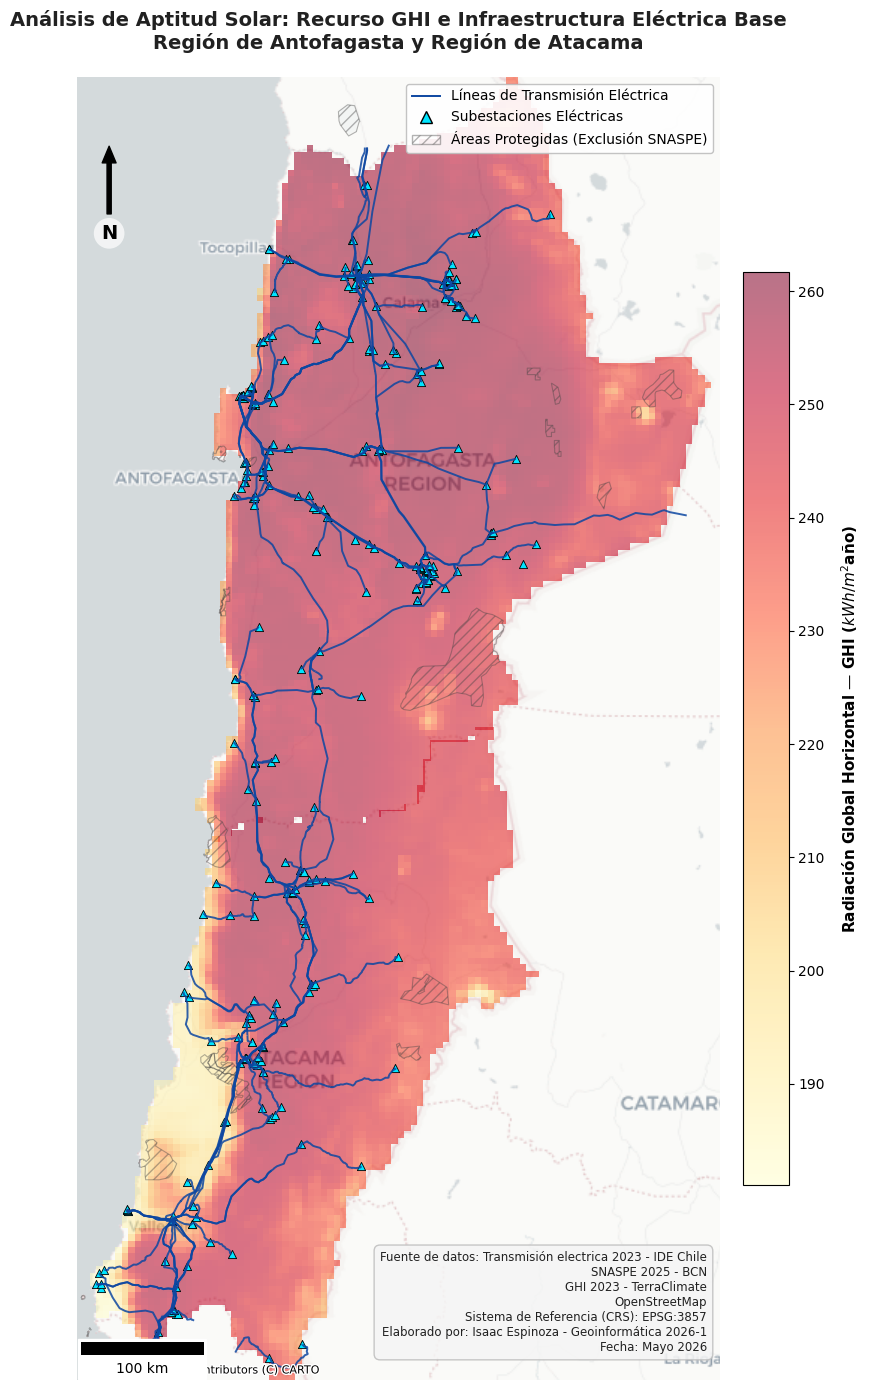

In [ ]:
"""Función auxiliar que ejecuta la reproyección de variables continuas en memoria.
Transforma píxeles de grados decimales a metros y enmascara los valores de NoData (océano)
como NaN para asegurar transparencia y correcta visibilidad del basemap."""
def reproyectar_raster_a_3857(ruta_raster):
    with rasterio.open(ruta_raster) as src:
        transform, width, height = calculate_default_transform(
            src.crs, 'EPSG:3857', src.width, src.height, *src.bounds
        )

        raster_proyectado = np.zeros((1, height, width), dtype=src.dtypes[0])

        reproject(
            source=rasterio.band(src, 1),
            destination=raster_proyectado[0],
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs='EPSG:3857',
            resampling=Resampling.bilinear
        )

        data = raster_proyectado[0].astype(float)

        nodata_val = src.nodata if src.nodata is not None else 0
        data[data == nodata_val] = np.nan
        data[data <= 10] = np.nan

        extent = [
            transform[2],
            transform[2] + transform[0]*width,
            transform[5] + transform[4]*height,
            transform[5]
        ]
        return data, extent


# 1. Reproyectar independientemente ambos archivos ráster de radiación regional
data_anto, extent_anto = reproyectar_raster_a_3857('ghi_2023_Antofagasta.tif')
data_atac, extent_atac = reproyectar_raster_a_3857('ghi_2023_Atacama.tif')


# 2. Crear el lienzo y el sistema de ejes
fig, ax = plt.subplots(figsize=(12, 14))


# 3. Encuantre de la vista (Usa la variable generada automáticamente en la celda anterior)
# Congelar la extensión geográfica real antes de invocar el basemap.
# Asegura que contextily descargue las baldosas exactas de la zona norte sin errores de zoom.
ax.set_xlim(limites_mapa[0], limites_mapa[2])
ax.set_ylim(limites_mapa[1], limites_mapa[3])


# 4. Basemap - Capa de fondo (Ground): Capa mapa base institucional atenuada al fondo
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=7)


# 5. Recurso solar GHI: Dato temático continuo (Figure). Uso de la paleta uniforme 'YlOrRd' para aptitud solar
vmin_global = min(np.nanmin(data_anto), np.nanmin(data_atac))
vmax_global = max(np.nanmax(data_anto), np.nanmax(data_atac))
im1 = ax.imshow(data_anto, cmap='YlOrRd', alpha=0.55, extent=extent_anto, origin='upper', vmin=vmin_global, vmax=vmax_global)
im2 = ax.imshow(data_atac, cmap='YlOrRd', alpha=0.55, extent=extent_atac, origin='upper', vmin=vmin_global, vmax=vmax_global)


# 6. Superposición de capas vectoriales (Estructura discreta e infraestructura de soporte)
snaspe_filtrado.plot(ax=ax, facecolor="none", edgecolor="#424242", linewidth=0.8, hatch="///", alpha=0.4)
lineas_filtrado.plot(ax=ax, color="#0D47A1", linewidth=1.4, alpha=0.85)
subestaciones_filtrado.plot(ax=ax, color="#00E5FF", markersize=35, marker="^", edgecolor="black", linewidth=0.6, alpha=1.0)





# CONSTRUCCIÓN DE LOS ELEMENTOS 7 OBLIGATORIOS Y EXPLICATIVOS


# Elemento 1: Título
ax.set_title("Análisis de Aptitud Solar: Recurso GHI e Infraestructura Eléctrica Base\nRegión de Antofagasta y Región de Atacama",
             fontsize=14, fontweight='bold', pad=20, color='#212121')


# Elemento 2: Leyenda integrada para variables vectoriales discretas
linea_proxy = Line2D([0], [0], color='#0D47A1', linewidth=1.4, label='Líneas de Transmisión Eléctrica')
punto_proxy = Line2D([0], [0], marker='^', color='none', markerfacecolor='#00E5FF', markeredgecolor='black', markersize=9, label='Subestaciones Eléctricas')
snaspe_proxy = Patch(facecolor='none', edgecolor='#424242', hatch='///', alpha=0.4, label='Áreas Protegidas (Exclusión SNASPE)')

ax.legend(handles=[linea_proxy, punto_proxy, snaspe_proxy], loc='upper right', framealpha=0.9, fontsize=10, facecolor='white', edgecolor='#BDBDBD')

# Barra de colores explicativa para la GHI, la variable cuantitativa continua
# Se posiciona a la derecha del mapa, indicando la unidad de medida.
cbar = fig.colorbar(im2, ax=ax, orientation='vertical', pad=0.02, shrink=0.7)
cbar.set_label('Radiación Global Horizontal — GHI ($kWh/m^2$año)', fontsize=11, fontweight='bold', labelpad=10)


# Elemento 3: Barra de escala gráfica espacial métrica
scalebar = ScaleBar(1, units='m', location='lower left')
ax.add_artist(scalebar)


# Elemento 4: Flecha de orientación Norte
ax.annotate('N', xy=(0.05, 0.95), xytext=(0.05, 0.88),
            arrowprops=dict(facecolor='black', width=3, headwidth=10, shrink=0.05),
            ha='center', va='center', fontsize=14, fontweight='bold',
            xycoords=ax.transAxes, bbox=dict(boxstyle='circle', facecolor='white', alpha=0.7, edgecolor='none'))


# Elementos 5, 6 y 7: Cuadro de metadatos abajo a la derecha
texto_fuente = (
    "Fuente de datos: Transmisión electrica 2023 - IDE Chile\n"
    "SNASPE 2025 - BCN\n"
    "GHI 2023 - TerraClimate\n"
    "OpenStreetMap\n"
    "Sistema de Referencia (CRS): EPSG:3857\n"
    "Elaborado por: Isaac Espinoza - Geoinformática 2026-1\n"
    "Fecha: Mayo 2026"
)
ax.text(0.98, 0.02, texto_fuente, transform=ax.transAxes, fontsize=8.5,
        fontname="sans-serif", color="#212121", ha='right', va='bottom',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#F5F5F5', alpha=0.85, edgecolor='#BDBDBD'))


# Ajuste final de visualización limpia (Sin ejes cartesianos de píxeles)
ax.set_axis_off()
plt.tight_layout()
plt.show()                  # Renderizar mapa completo

Exportación a PNG


In [ ]:
# Guardar el mapa final en formato de imagen png
ruta_salida = 'mapa_aptitud_solar_II_III_region.png'

fig.savefig(ruta_salida,
            dpi=300,
            bbox_inches='tight',
            facecolor='white',
            edgecolor='none')

print(f"✔️ ¡Éxito! El mapa ha sido exportado correctamente.")

✔️ ¡Éxito! El mapa ha sido exportado correctamente.
